# Notebook 01 — Data Exploration
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/polar-bear-after-lunch/AareML/blob/main/notebooks/01_data_exploration.ipynb)

Exploratory data analysis of CAMELS-CH-Chem: data availability, sensor coverage, seasonal patterns, land cover composition, and NAWA chemistry distributions across 86 Swiss gauging stations.

# AareML — 01: Data Exploration

**Project:** AareML — Predicting River Water Quality in Swiss Catchments  
**Dataset:** CAMELS-CH-Chem (Nascimento et al., 2025)  
**Reference benchmark:** LakeBeD-US (McAfee et al., 2025)

This notebook covers:
1. Data loading and folder structure
2. Gauge metadata overview and spatial coverage
3. High-frequency sensor time series (daily: temp, DO, pH, EC)
4. Data availability matrix across all 86 stations
5. Descriptive statistics and distributions
6. Seasonal patterns
7. Correlation analysis
8. NAWA FRACHT low-frequency chemistry overview
9. Catchment attributes (land cover, atmospheric deposition)
10. Stationarity and missing value summary

## 0. Setup

In [1]:
# ── Colab setup (auto-runs only in Google Colab) ──────────────────────────
import sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import os
    from pathlib import Path

    # ── 1. Clone repo ──────────────────────────────────────────────────────
    if not Path('AareML').exists():
        os.system('git clone https://github.com/polar-bear-after-lunch/AareML.git')
    if not str(Path.cwd()).endswith('AareML'):
        os.chdir('AareML')

    # ── 2. Install dependencies ────────────────────────────────────────────
    os.system('pip install -q -r requirements.txt')

    # ── 3. Mount Google Drive for persistent data storage ─────────────────
    from google.colab import drive
    drive.mount('/content/drive')

    # Data stored in Drive so it survives across sessions (~360 MB total)
    DRIVE_DATA = Path('/content/drive/MyDrive/AareML_data')
    LOCAL_DATA = Path('data')
    LOCAL_DATA.mkdir(exist_ok=True)

    # ── 4. CAMELS-CH-Chem ─────────────────────────────────────────────────
    DRIVE_CAMELS = DRIVE_DATA / 'camels-ch-chem'
    LOCAL_CAMELS = LOCAL_DATA / 'camels-ch-chem'

    if DRIVE_CAMELS.exists():
        # Already in Drive — symlink to local path (fast, no re-download)
        if not LOCAL_CAMELS.exists():
            os.system(f'ln -s {DRIVE_CAMELS} {LOCAL_CAMELS}')
        print('CAMELS-CH-Chem loaded from Google Drive.')
    else:
        # First time — download to Drive
        print('Downloading CAMELS-CH-Chem to Google Drive (~165 MB, one-time)...')
        DRIVE_DATA.mkdir(parents=True, exist_ok=True)
        os.system(
            'wget -q --show-progress -O /tmp/camels.zip '
            '"https://zenodo.org/api/records/14980027/files/camels-ch-chem.zip/content"'
        )
        os.system(f'unzip -q /tmp/camels.zip -d {DRIVE_CAMELS}')
        os.system('rm /tmp/camels.zip')
        os.system(f'ln -s {DRIVE_CAMELS} {LOCAL_CAMELS}')
        print('CAMELS-CH-Chem saved to Google Drive for future sessions.')

    print(f'Setup complete. Working directory: {os.getcwd()}')


In [2]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

# Optional: geopandas for maps (comment out if not installed)
try:
    import geopandas as gpd
    HAS_GEOPANDAS = True
except ImportError:
    HAS_GEOPANDAS = False
    print('geopandas not available — map plots will be skipped')

# Optional: statsmodels for stationarity tests
try:
    from statsmodels.tsa.stattools import adfuller
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print('statsmodels not available — ADF tests will be skipped')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
# Auto-detect repo root (works both locally and in Colab after os.chdir)
# G-U2 fix: use Path('.') when figures/ exists (repo root), else Path('..')
_repo_root = Path('.') if Path('figures').exists() else Path('..')
DATA_ROOT   = _repo_root / 'data' / 'camels-ch-chem'
FIGURES_DIR = _repo_root / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

DAILY_DIR      = DATA_ROOT / 'stream_water_chemistry/timeseries/daily'
HOURLY_DIR     = DATA_ROOT / 'stream_water_chemistry/timeseries/hourly'
NAWAF_DIR      = DATA_ROOT / 'stream_water_chemistry/interval_samples/nawa_fracht'
NAWAT_DIR      = DATA_ROOT / 'stream_water_chemistry/interval_samples/nawa_trend'
LANDCOVER_DIR  = DATA_ROOT / 'catchment_aggregated_data/landcover_data'
ATMDEPO_DIR    = DATA_ROOT / 'catchment_aggregated_data/atmospheric_deposition'
LIVESTOCK_DIR  = DATA_ROOT / 'catchment_aggregated_data/livestock_data'
AGRI_DIR       = DATA_ROOT / 'catchment_aggregated_data/agricultural_data'
METADATA_FILE  = DATA_ROOT / 'gauges_metadata/camels_ch_chem_gauges_metadata.csv'
SHAPEFILE      = DATA_ROOT / 'shapefiles/camels_ch_del/camels_ch_chem_gauging_stations.shp'

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f'Data not found at {DATA_ROOT.resolve()}. '
        f'Run: python download_data.py --camels'
    )
print('Data root found:', DATA_ROOT.resolve())

# Shapefile is optional — skip map if not present
if not SHAPEFILE.exists():
    print(f'Shapefile not found (optional): {SHAPEFILE}')
    print('Station map will be skipped — all other cells will run normally.')

Data root found: /Users/amber/VS Code/polar-bear-after-lunch/AareML/data/camels-ch-chem


## 1. Gauge Metadata

In [4]:
meta = pd.read_csv(METADATA_FILE)
print(f'Total gauges: {len(meta)}')
print(f'Columns: {list(meta.columns)}')
meta.head()

Total gauges: 115
Columns: ['gauge_id', 'sensor_id', 'nawaf_id', 'nawat_id', 'isot_id', 'chirp_id', 'gauge_name', 'water_body_name', 'gauge_easting', 'gauge_northing', 'gauge_lon', 'gauge_lat', 'area', 'area_swiss_perc', 'Q', 'level', 'gauge_name_nawaf', 'gauge_easting_nawaf', 'gauge_northing_nawaf', 'area_nawaf', 'foen_nawaf_dist', 'gauge_name_nawat', 'gauge_easting_nawat', 'gauge_northing_nawat', 'area_nawat', 'foen_nawat_dist', 'q_nawat_corrector', 'remarks']


,gauge_id,sensor_id,nawaf_id,nawat_id,isot_id,chirp_id,gauge_name,water_body_name,gauge_easting,gauge_northing,...,gauge_northing_nawaf,area_nawaf,foen_nawaf_dist,gauge_name_nawat,gauge_easting_nawat,gauge_northing_nawat,area_nawat,foen_nawat_dist,q_nawat_corrector,remarks
0,2009,2009.0,1837.0,1837.0,NIO04,NaN,Porte du Scex,Rhône,2557660,1133280,...,1133280.0,5239.4,0.0,Porte du Scex,2557660.0,1133280.0,5239.402096,0.0,1.000,NaN
1,2011,2011.0,NaN,4070.0,NaN,NaN,Sion,Rhône,2593770,1118630,...,NaN,NaN,NaN,Sion,2593277.0,1118449.0,3372.417040,0.0,1.000,NaN
2,2016,2016.0,1833.0,1833.0,NIO02,NaN,Brugg,Aare,2657000,1259360,...,1259360.0,11681.3,0.0,Brugg,2657000.0,1259360.0,11681.282882,0.0,1.000,NaN
3,2018,2018.0,1835.0,1339.0,NaN,NaN,Mellingen,Reuss,2662830,1252580,...,1252580.0,3385.8,0.0,Gebenstorf,2659450.0,1258850.0,3420.503458,10.0,1.010,NaN
4,2019,2019.0,NaN,1852.0,NIO01,NaN,Brienzwiler,Aare,2649930,1177380,...,NaN,NaN,NaN,Brienzerseeeinlauf,2646692.0,1177000.0,555.808970,3.3,1.001,NaN


In [5]:
# Availability flags: which gauges have which data sources
meta['has_sensor']  = meta['sensor_id'].notna()
meta['has_nawaf']   = meta['nawaf_id'].notna()
meta['has_nawat']   = meta['nawat_id'].notna()
meta['has_isot']    = meta['isot_id'].notna()

print('\nData source availability:')
print(meta[['has_sensor','has_nawaf','has_nawat','has_isot']].sum().to_string())


Data source availability:
has_sensor    86
has_nawaf     24
has_nawat     76
has_isot       9


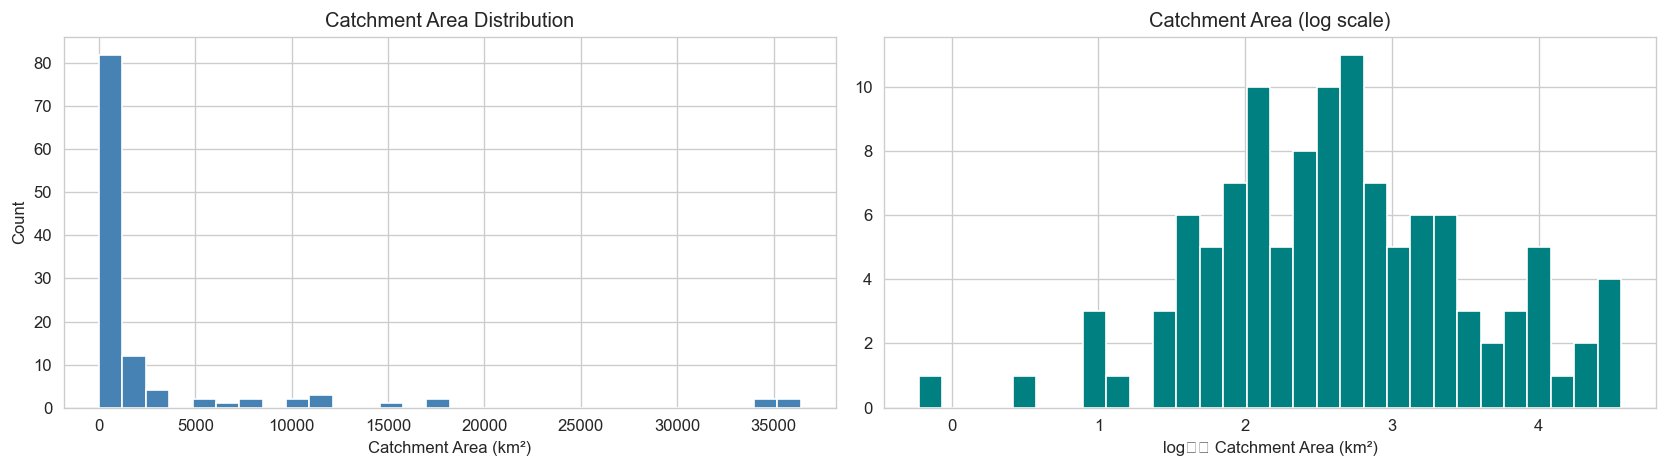

count      115.000000
mean      2949.807826
std       7099.277645
min          0.600000
25%        105.300000
50%        415.900000
75%       1657.450000
max      36404.400000
Name: area, dtype: float64


In [6]:
# Catchment area distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(meta['area'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Catchment Area (km²)')
axes[0].set_ylabel('Count')
axes[0].set_title('Catchment Area Distribution')

axes[1].hist(np.log10(meta['area'].dropna()), bins=30, color='teal', edgecolor='white')
axes[1].set_xlabel('log₁₀ Catchment Area (km²)')
axes[1].set_title('Catchment Area (log scale)')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_catchment_area_distribution.png', bbox_inches='tight')
plt.show()
print(meta['area'].describe())

## 2. Spatial Coverage Map

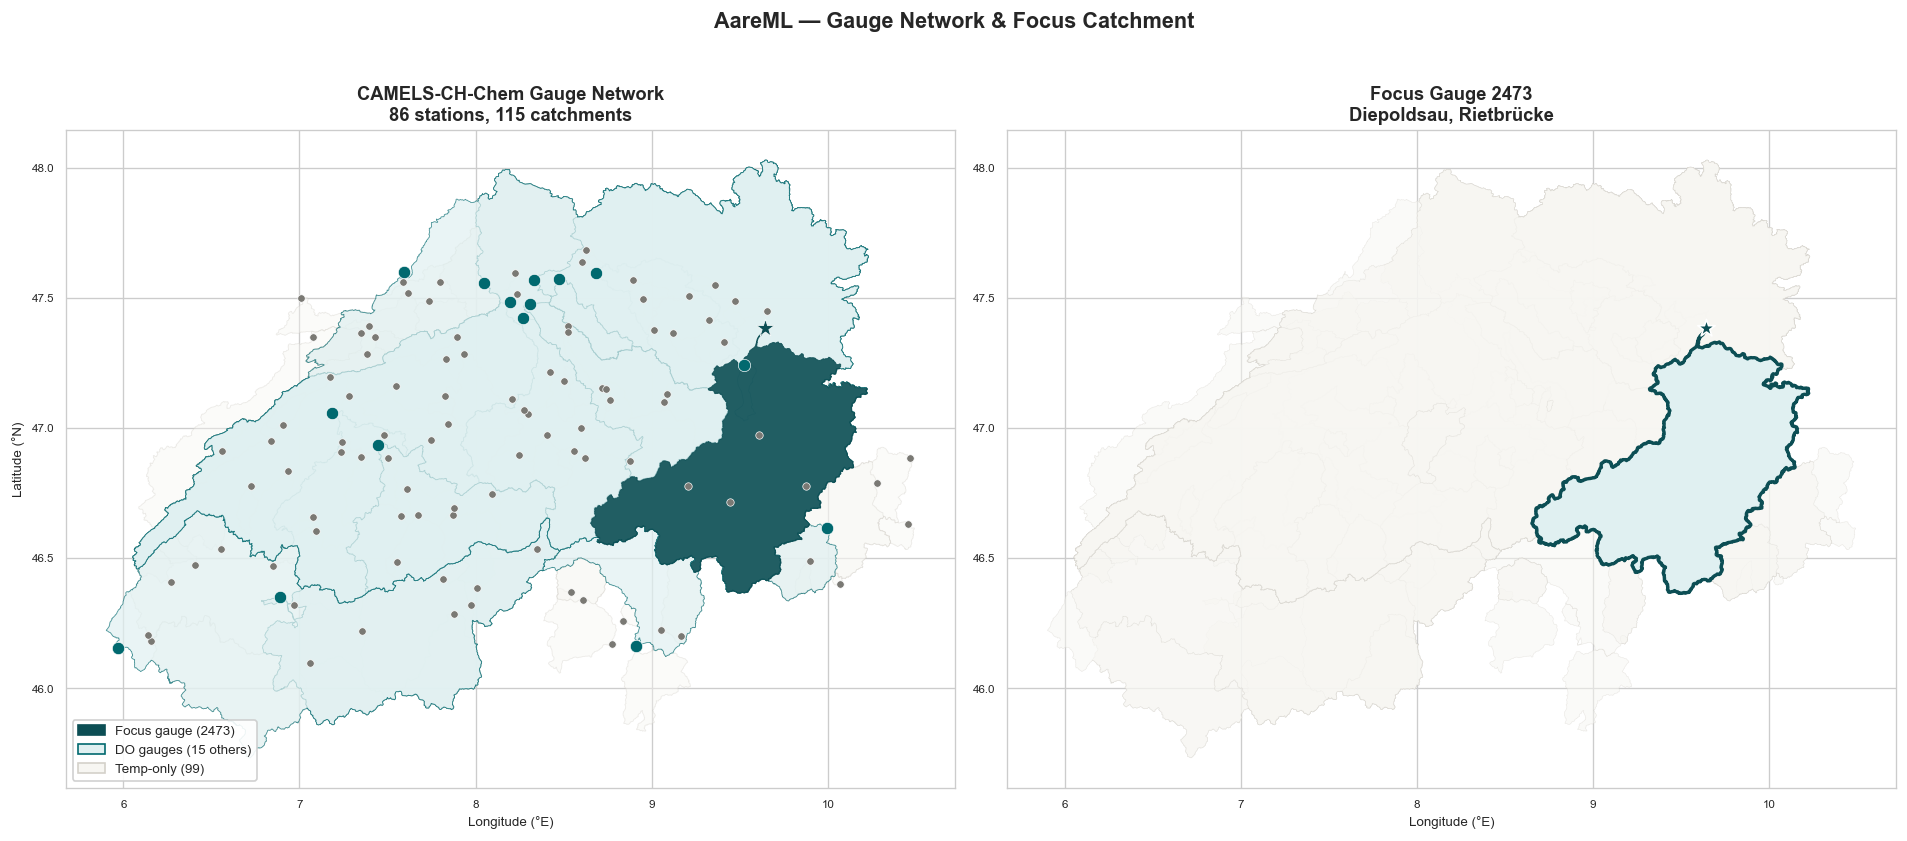

Map saved: DO gauges=16, temp-only=99


In [7]:
# ── Switzerland gauge + catchment map ──────────────────────────────────────
import sys; sys.path.insert(0, '..')
from src.config import FOCUS_GAUGE
import matplotlib.patches as mpatches

# Identify DO-capable gauges
do_gauges = []
for csv_file in sorted(DAILY_DIR.glob('*.csv')):
    try:
        df_tmp = pd.read_csv(csv_file, parse_dates=['date'], index_col='date')
        if 'O2C_sensor' in df_tmp.columns and df_tmp['O2C_sensor'].notna().mean() >= 0.10:
            gid = csv_file.stem.split('_')[-1]
            do_gauges.append(str(gid))
    except Exception:
        pass

if HAS_GEOPANDAS and SHAPEFILE.exists():
    catchments = gpd.read_file(str(DATA_ROOT / 'shapefiles/camels_ch_del/camels_ch_chem_catchment_boundaries.shp'))
    gauges_shp  = gpd.read_file(SHAPEFILE)
    catchments  = catchments.to_crs(epsg=4326)
    gauges_shp  = gauges_shp.to_crs(epsg=4326)

    def get_cat(gid):
        gid = str(gid)
        if gid == str(FOCUS_GAUGE): return 'focus'
        elif gid in do_gauges: return 'do'
        else: return 'temp_only'

    catchments['cat'] = catchments['gauge_id'].astype(str).map(get_cat)
    gauges_shp['cat']  = gauges_shp['gauge_id'].astype(str).map(get_cat)

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # ── Left: full Switzerland network map ────────────────────────────────
    ax = axes[0]
    c_map  = {'focus': '#0C4E54', 'do': '#E0F0F1', 'temp_only': '#F7F6F2'}
    ec_map = {'focus': '#0C4E54', 'do': '#01696F', 'temp_only': '#D4D1CA'}
    for cat in ['temp_only', 'do', 'focus']:
        sub = catchments[catchments['cat'] == cat]
        if len(sub): sub.plot(ax=ax, color=c_map[cat], edgecolor=ec_map[cat], linewidth=0.5,
                               alpha={'temp_only':0.4,'do':0.7,'focus':0.9}[cat],
                               zorder={'temp_only':1,'do':2,'focus':3}[cat])
    pt_c = {'focus':'#0C4E54','do':'#01696F','temp_only':'#7A7974'}
    pt_s = {'focus':120,'do':55,'temp_only':20}
    pt_m = {'focus':'*','do':'o','temp_only':'o'}
    for cat in ['temp_only','do','focus']:
        sub = gauges_shp[gauges_shp['cat']==cat]
        if len(sub): sub.plot(ax=ax, color=pt_c[cat], markersize=pt_s[cat],
                               marker=pt_m[cat], zorder={'temp_only':4,'do':6,'focus':10}[cat],
                               edgecolor='white', linewidth=0.4)
    ax.legend(handles=[
        mpatches.Patch(fc=c_map['focus'],    ec=ec_map['focus'],    label=f'Focus gauge ({FOCUS_GAUGE})'),
        mpatches.Patch(fc=c_map['do'],       ec=ec_map['do'],       label=f'DO gauges ({len(do_gauges)-1} others)'),
        mpatches.Patch(fc=c_map['temp_only'],ec=ec_map['temp_only'],label=f'Temp-only ({len(meta)-len(do_gauges)})'),
    ], fontsize=8, loc='lower left', framealpha=0.9)
    ax.set_title('CAMELS-CH-Chem Gauge Network\n86 stations, 115 catchments', fontsize=11, fontweight='bold')
    ax.set_xlabel('Longitude (°E)', fontsize=8); ax.set_ylabel('Latitude (°N)', fontsize=8)
    ax.tick_params(labelsize=7)

    # ── Right: focus gauge catchment detail ───────────────────────────────
    ax = axes[1]
    catchments.plot(ax=ax, color='#F7F6F2', edgecolor='#D4D1CA', linewidth=0.3, alpha=0.5, zorder=1)
    catchments[catchments['cat']=='focus'].plot(ax=ax, color='#E0F0F1', edgecolor='#0C4E54', linewidth=2, zorder=2)
    gauges_shp[gauges_shp['cat']=='focus'].plot(ax=ax, color='#0C4E54', markersize=120, marker='*',
                                                  zorder=5, edgecolor='white', linewidth=1)
    focus_name = meta[meta['gauge_id'].astype(str)==str(FOCUS_GAUGE)]['gauge_name'].values
    ax.set_title(f'Focus Gauge {FOCUS_GAUGE}\n{focus_name[0] if len(focus_name) else ""}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Longitude (°E)', fontsize=8); ax.tick_params(labelsize=7)

    plt.suptitle('AareML — Gauge Network & Focus Catchment', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '01_station_map.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Map saved: DO gauges={len(do_gauges)}, temp-only={len(meta)-len(do_gauges)}')

else:
    # Fallback scatter if geopandas unavailable
    fig, ax = plt.subplots(figsize=(12, 7))
    temp_only = meta[~meta['gauge_id'].astype(str).isin(do_gauges)]
    do_meta   = meta[meta['gauge_id'].astype(str).isin(do_gauges) & (meta['gauge_id'].astype(str) != str(FOCUS_GAUGE))]
    focus_meta_row = meta[meta['gauge_id'].astype(str) == str(FOCUS_GAUGE)]
    ax.scatter(temp_only['gauge_lon'], temp_only['gauge_lat'], c='#D4D1CA', s=30, label=f'Temp-only ({len(temp_only)})', zorder=2)
    ax.scatter(do_meta['gauge_lon'],   do_meta['gauge_lat'],   c='#01696F', s=70, label=f'DO gauges ({len(do_meta)})', zorder=3)
    ax.scatter(focus_meta_row['gauge_lon'], focus_meta_row['gauge_lat'], c='#0C4E54', s=200, marker='*',
               label=f'Focus gauge ({FOCUS_GAUGE})', zorder=5, edgecolor='white')
    ax.set_xlabel('Longitude (°E)'); ax.set_ylabel('Latitude (°N)')
    ax.set_title('CAMELS-CH-Chem Gauge Locations — Switzerland', fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '01_station_map.png', dpi=150, bbox_inches='tight')
    plt.show()


## 3. Load All Daily Time Series

In [8]:
# Load all 86 daily sensor files into a dict: {gauge_id: DataFrame}
SENSOR_COLS = ['temp_sensor', 'pH_sensor', 'ec_sensor', 'O2C_sensor']

daily_data = {}
for fpath in sorted(DAILY_DIR.glob('camels_ch_chem_daily_*.csv')):
    gauge_id = int(fpath.stem.split('_')[-1])
    df = pd.read_csv(fpath, parse_dates=['date'], index_col='date')
    # Coerce numeric (some files may have '<0.5' style values)
    for col in SENSOR_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    daily_data[gauge_id] = df

print(f'Loaded {len(daily_data)} daily sensor files')
print(f'Date range (sample): {list(daily_data.values())[0].index.min()} → {list(daily_data.values())[0].index.max()}')
list(daily_data.values())[0].head()

Loaded 86 daily sensor files
Date range (sample): 1981-01-01 00:00:00 → 2020-12-31 00:00:00


,temp_sensor,pH_sensor,ec_sensor,O2C_sensor
date,,,,
1981-01-01,2.7,7.87,363.9,11.18
1981-01-02,3.3,7.92,424.1,11.02
1981-01-03,3.9,7.90,363.8,10.96
1981-01-04,4.3,7.89,378.7,10.60
1981-01-05,3.8,7.89,383.3,10.52


## 4. Data Availability Matrix

In [9]:
# For each gauge and each sensor column: compute % non-null
availability = []
for gauge_id, df in daily_data.items():
    row = {'gauge_id': gauge_id}
    for col in SENSOR_COLS:
        if col in df.columns:
            pct = df[col].notna().mean() * 100
        else:
            pct = 0.0
        row[col] = pct
    availability.append(row)

avail_df = pd.DataFrame(availability).set_index('gauge_id')
avail_df = avail_df.sort_values('O2C_sensor', ascending=False)

# Gauges with DO data (O2C_sensor > 10% available)
do_gauges = avail_df[avail_df['O2C_sensor'] > 10].index.tolist()
print(f'Gauges with meaningful DO data (>10% available): {len(do_gauges)}')
print(do_gauges)

Gauges with meaningful DO data (>10% available): 16
[2473, 2009, 2613, 2143, 2016, 2174, 2415, 2044, 2410, 2085, 2462, 2018, 2243, 2068, 2135, 2130]


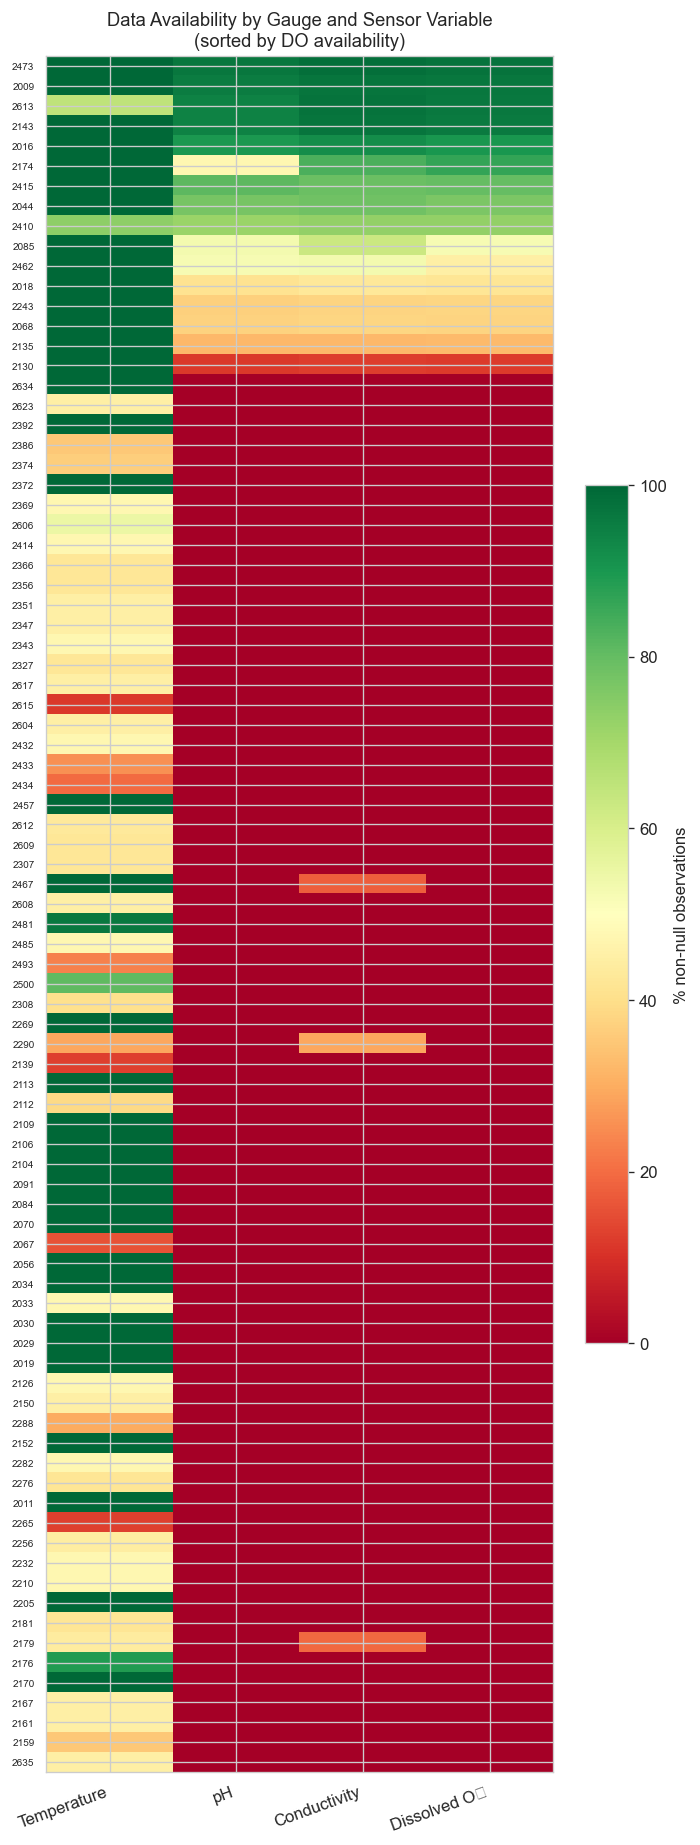

In [10]:
fig, ax = plt.subplots(figsize=(6, max(6, len(avail_df) * 0.18)))

im = ax.imshow(avail_df.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label='% non-null observations', shrink=0.5)

ax.set_xticks(range(len(avail_df.columns)))
ax.set_xticklabels(['Temperature', 'pH', 'Conductivity', 'Dissolved O₂'], rotation=20, ha='right')
ax.set_yticks(range(len(avail_df)))
ax.set_yticklabels(avail_df.index, fontsize=6)
ax.set_title('Data Availability by Gauge and Sensor Variable\n(sorted by DO availability)', fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_data_availability_matrix.png', bbox_inches='tight')
plt.show()

## 5. Temporal Coverage per Gauge

In [11]:
# For each gauge: find first and last non-null date for each variable
coverage = []
for gauge_id, df in daily_data.items():
    row = {'gauge_id': gauge_id}
    for col in SENSOR_COLS:
        if col in df.columns and df[col].notna().any():
            valid = df[col].dropna()
            row[f'{col}_start'] = valid.index.min()
            row[f'{col}_end']   = valid.index.max()
            row[f'{col}_years'] = (valid.index.max() - valid.index.min()).days / 365.25
        else:
            row[f'{col}_start'] = pd.NaT
            row[f'{col}_end']   = pd.NaT
            row[f'{col}_years'] = 0
    coverage.append(row)

cov_df = pd.DataFrame(coverage).set_index('gauge_id')

print('\nDistribution of record lengths (years) per variable:')
for col in SENSOR_COLS:
    vals = cov_df[f'{col}_years'].replace(0, np.nan).dropna()
    print(f'  {col:20s}: n={len(vals):3d}, median={vals.median():.1f}y, max={vals.max():.1f}y')


Distribution of record lengths (years) per variable:
  temp_sensor         : n= 86, median=20.5y, max=40.0y
  pH_sensor           : n= 16, median=37.5y, max=40.0y
  ec_sensor           : n= 19, median=35.0y, max=40.0y
  O2C_sensor          : n= 16, median=40.0y, max=40.0y


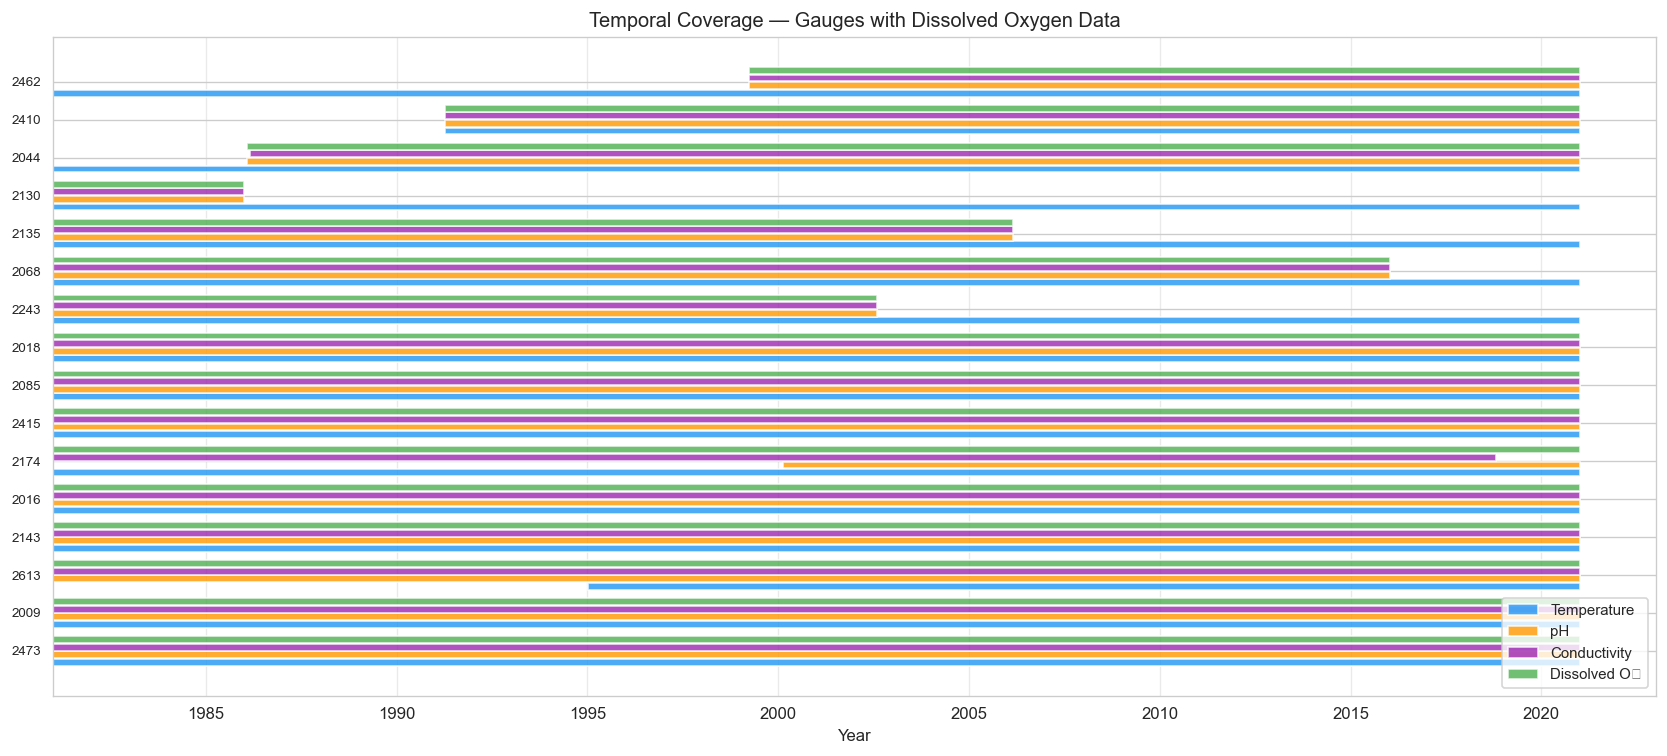

In [12]:
# Gantt-style temporal coverage chart for DO gauges
do_cov = cov_df.loc[[g for g in do_gauges if g in cov_df.index]].copy()
do_cov = do_cov.sort_values('O2C_sensor_start')

fig, ax = plt.subplots(figsize=(14, max(4, len(do_cov) * 0.4)))

colors = {'temp_sensor': '#2196F3', 'O2C_sensor': '#4CAF50', 
          'pH_sensor': '#FF9800', 'ec_sensor': '#9C27B0'}
labels = {'temp_sensor': 'Temperature', 'O2C_sensor': 'Dissolved O₂',
          'pH_sensor': 'pH', 'ec_sensor': 'Conductivity'}

y_positions = range(len(do_cov))
offsets = [-0.3, -0.1, 0.1, 0.3]

for i, (gauge_id, row) in enumerate(do_cov.iterrows()):
    for j, col in enumerate(SENSOR_COLS):
        start = row[f'{col}_start']
        end   = row[f'{col}_end']
        if pd.notna(start) and pd.notna(end):
            ax.barh(i + offsets[j],
                    (end - start).days / 365.25,
                    left=start.year + start.dayofyear/365.25,
                    height=0.18,
                    color=colors[col], alpha=0.8, label=labels[col] if i == 0 else '')

ax.set_yticks(list(y_positions))
ax.set_yticklabels([str(g) for g in do_cov.index], fontsize=8)
ax.set_xlabel('Year')
ax.set_title('Temporal Coverage — Gauges with Dissolved Oxygen Data')
handles, lbls = ax.get_legend_handles_labels()
seen = dict(zip(lbls, handles))
ax.legend(seen.values(), seen.keys(), loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_temporal_coverage_do_gauges.png', bbox_inches='tight')
plt.show()

## 6. Descriptive Statistics

In [13]:
# Pool all observations across all gauges
all_obs = pd.concat(
    [df[SENSOR_COLS] for df in daily_data.values()],
    ignore_index=True
)

print('=== Pooled descriptive statistics across all 86 gauges ===')
all_obs.describe().round(3)

=== Pooled descriptive statistics across all 86 gauges ===


,temp_sensor,pH_sensor,ec_sensor,O2C_sensor
count,844335.000,147946.000,166669.000,153578.000
mean,9.411,8.054,362.249,10.688
std,5.309,0.192,106.088,1.319
min,-1.950,0.000,-500.200,4.570
25%,5.500,7.950,296.200,9.700
50%,8.320,8.080,346.100,10.750
75%,12.950,8.180,416.900,11.660
max,28.800,8.840,1239.500,15.680


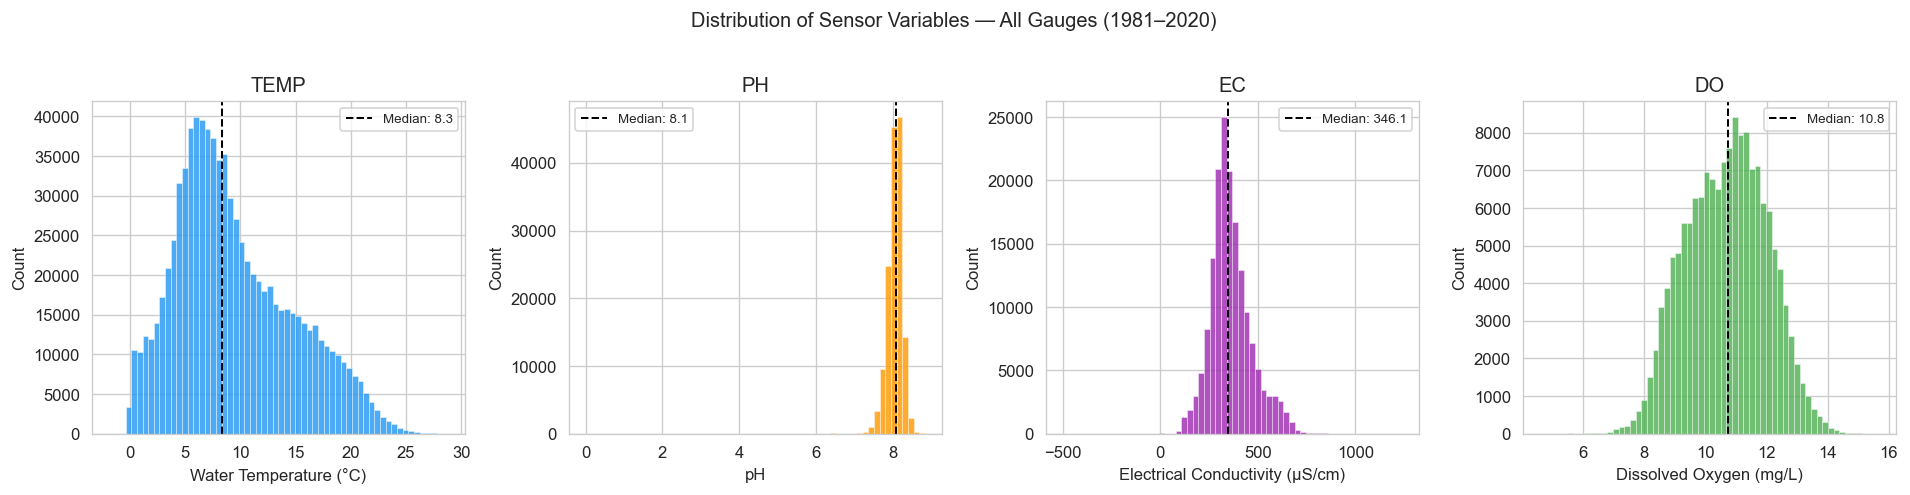

In [14]:
# Distribution plots for each sensor variable
var_labels = {
    'temp_sensor': 'Water Temperature (°C)',
    'pH_sensor':   'pH',
    'ec_sensor':   'Electrical Conductivity (µS/cm)',
    'O2C_sensor':  'Dissolved Oxygen (mg/L)'
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['#2196F3', '#FF9800', '#9C27B0', '#4CAF50']

for ax, col, color in zip(axes, SENSOR_COLS, colors):
    data = all_obs[col].dropna()
    ax.hist(data, bins=60, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(data.median(), color='black', linestyle='--', linewidth=1.2, label=f'Median: {data.median():.1f}')
    ax.set_xlabel(var_labels[col])
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    ax.set_title(col.replace('_sensor', '').replace('O2C', 'DO').upper())

plt.suptitle('Distribution of Sensor Variables — All Gauges (1981–2020)', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_variable_distributions.png', bbox_inches='tight')
plt.show()

## 7. Single-Gauge Deep Dive — Focus Station

In [15]:
# Select focus gauge: best DO coverage (top of sorted list)
FOCUS_GAUGE = do_gauges[0]
focus_meta  = meta[meta['gauge_id'] == FOCUS_GAUGE].iloc[0]
focus_df    = daily_data[FOCUS_GAUGE].copy()

print(f'Focus gauge: {FOCUS_GAUGE}')
print(f'Name: {focus_meta["gauge_name"]} — {focus_meta["water_body_name"]}')
print(f'Area: {focus_meta["area"]:.0f} km²')
print(f'Date range: {focus_df.index.min().date()} → {focus_df.index.max().date()}')
print(f'DO availability: {focus_df["O2C_sensor"].notna().mean()*100:.1f}%')
focus_df.describe().round(3)

Focus gauge: 2473
Name: Diepoldsau, Rietbrücke — Rhein
Area: 6297 km²
Date range: 1981-01-01 → 2020-12-31
DO availability: 97.3%


,temp_sensor,pH_sensor,ec_sensor,O2C_sensor
count,14610.000,14145.000,14330.000,14218.000
mean,8.084,8.105,296.333,11.333
std,3.522,0.120,55.956,0.913
min,0.000,7.650,161.300,8.760
25%,5.000,8.030,254.000,10.630
50%,8.095,8.120,296.600,11.270
75%,10.940,8.190,335.500,12.050
max,18.330,8.550,481.700,13.870


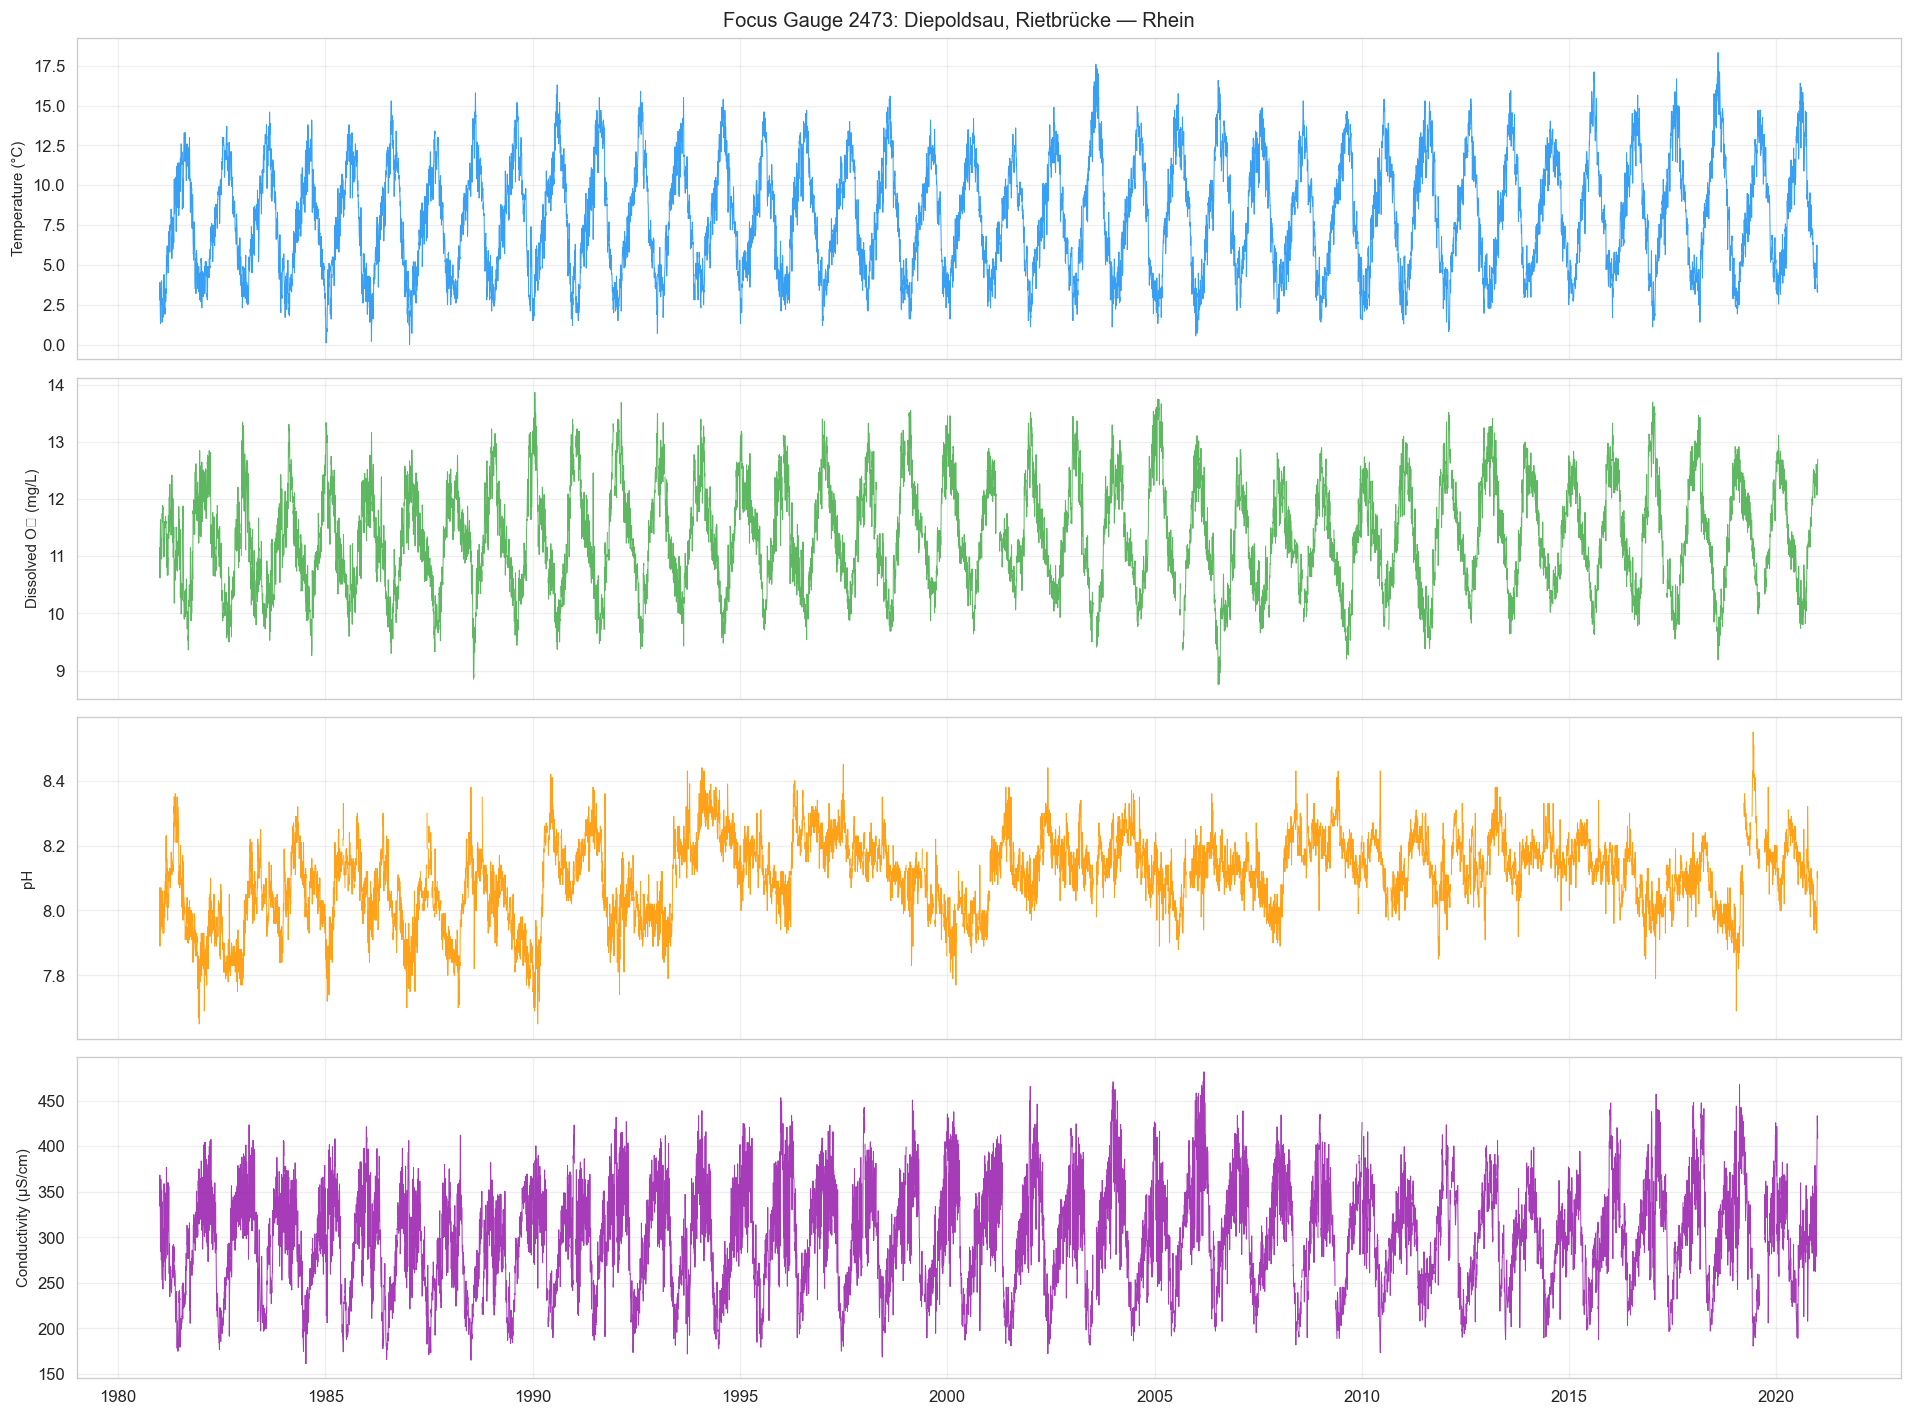

In [16]:
# Full time series plot for focus gauge
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

plot_vars = [
    ('temp_sensor', 'Temperature (°C)',      '#2196F3'),
    ('O2C_sensor',  'Dissolved O₂ (mg/L)',   '#4CAF50'),
    ('pH_sensor',   'pH',                    '#FF9800'),
    ('ec_sensor',   'Conductivity (µS/cm)',  '#9C27B0'),
]

for ax, (col, ylabel, color) in zip(axes, plot_vars):
    if col in focus_df.columns:
        ax.plot(focus_df.index, focus_df[col], color=color, linewidth=0.6, alpha=0.9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'{col} not available', transform=ax.transAxes,
                ha='center', va='center', color='grey')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.suptitle(f'Focus Gauge {FOCUS_GAUGE}: {focus_meta["gauge_name"]} — {focus_meta["water_body_name"]}',
             fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_timeseries_gauge_{FOCUS_GAUGE}.png', bbox_inches='tight')
plt.show()

## 8. Seasonal Patterns

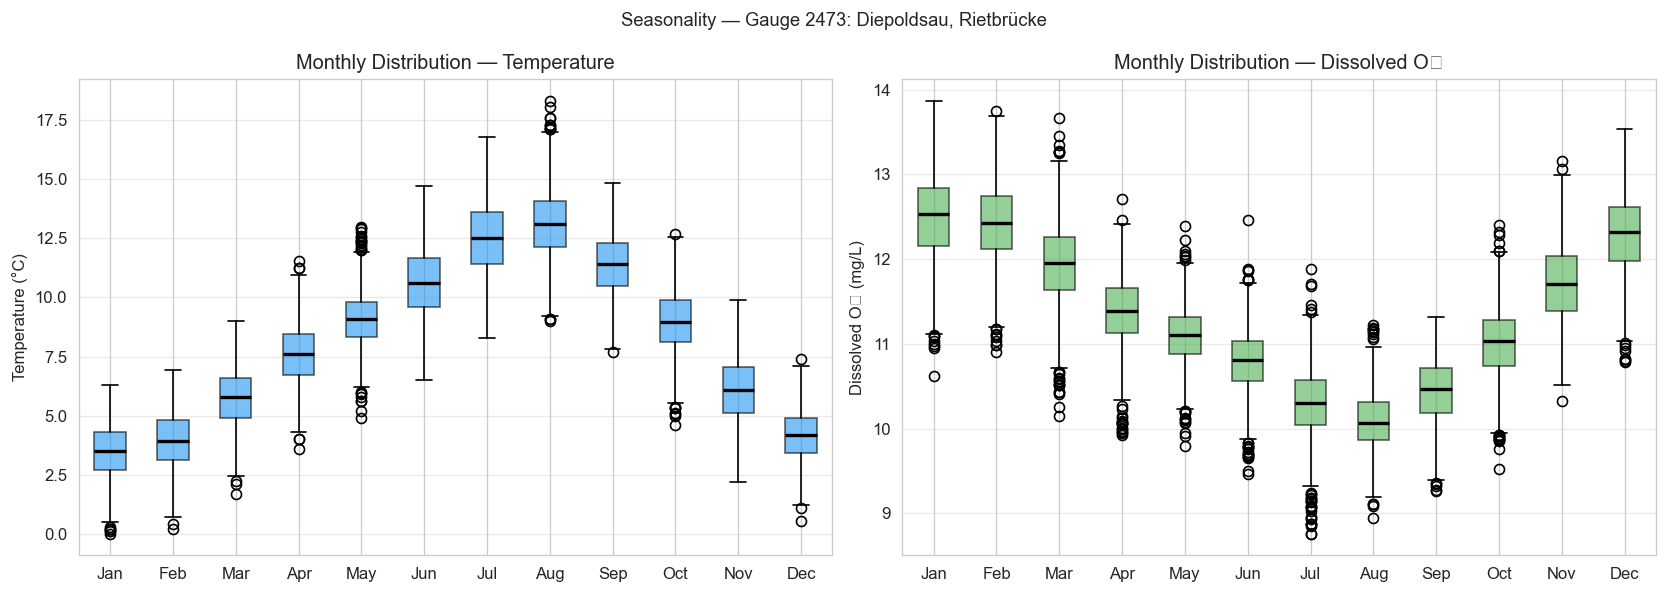

In [17]:
# Monthly boxplots for focus gauge — temperature and DO
focus_df['month'] = focus_df.index.month
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (col, ylabel, color) in zip(axes, [
    ('temp_sensor', 'Temperature (°C)', '#2196F3'),
    ('O2C_sensor',  'Dissolved O₂ (mg/L)', '#4CAF50')
]):
    if col in focus_df.columns and focus_df[col].notna().any():
        monthly = [focus_df[focus_df['month'] == m][col].dropna().values
                   for m in range(1, 13)]
        bp = ax.boxplot(monthly, labels=month_labels, patch_artist=True,
                        medianprops=dict(color='black', linewidth=2),
                        boxprops=dict(facecolor=color, alpha=0.6))
        ax.set_ylabel(ylabel)
        ax.set_title(f'Monthly Distribution — {ylabel.split(" (")[0]}')
        ax.grid(axis='y', alpha=0.4)

plt.suptitle(f'Seasonality — Gauge {FOCUS_GAUGE}: {focus_meta["gauge_name"]}', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_seasonality_gauge_{FOCUS_GAUGE}.png', bbox_inches='tight')
plt.show()

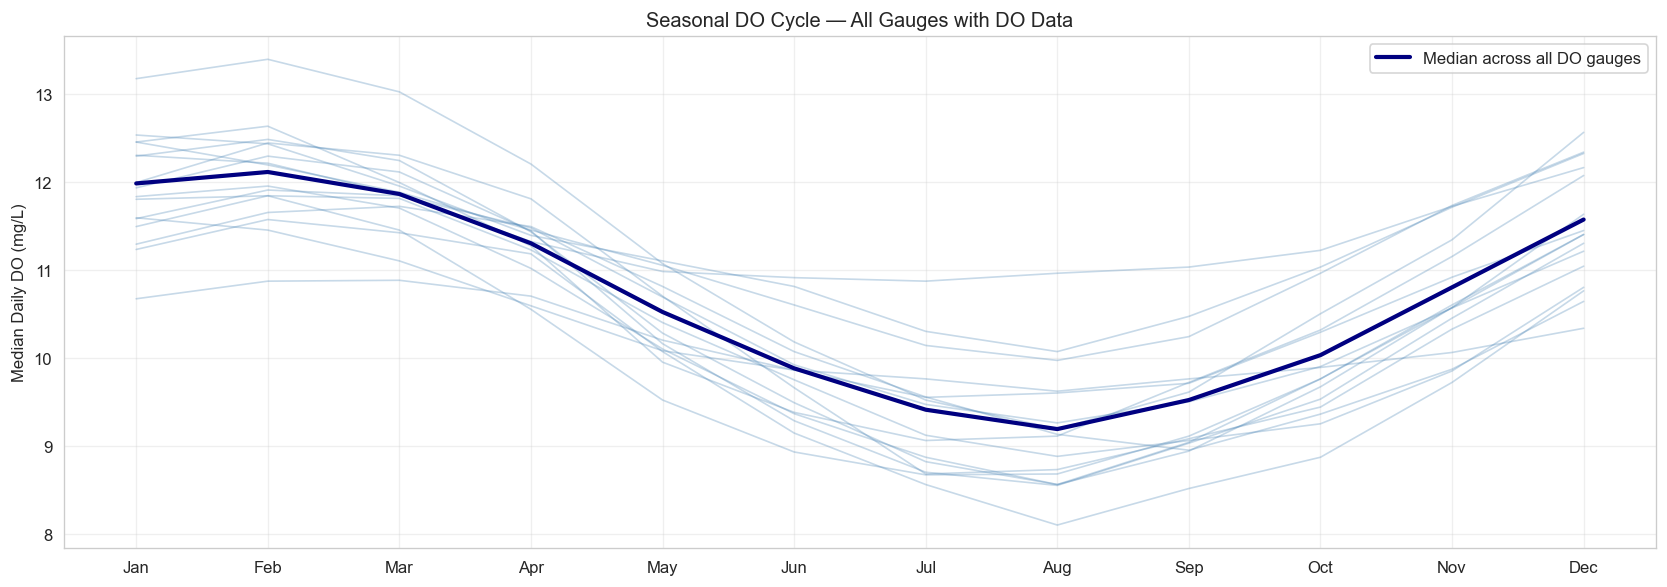

In [18]:
# Seasonal comparison across ALL do_gauges: monthly median DO
fig, ax = plt.subplots(figsize=(14, 5))

for gauge_id in do_gauges:
    df = daily_data[gauge_id]
    if 'O2C_sensor' in df.columns and df['O2C_sensor'].notna().any():
        monthly_median = df.groupby(df.index.month)['O2C_sensor'].median()
        ax.plot(monthly_median.index, monthly_median.values,
                alpha=0.3, linewidth=1, color='steelblue')

# Pooled median across all gauges
pool = pd.concat([daily_data[g]['O2C_sensor'] for g in do_gauges
                  if 'O2C_sensor' in daily_data[g].columns])
pool_month = pool.groupby(pool.index.month).median()
ax.plot(pool_month.index, pool_month.values, color='navy',
        linewidth=2.5, label='Median across all DO gauges', zorder=5)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_ylabel('Median Daily DO (mg/L)')
ax.set_title('Seasonal DO Cycle — All Gauges with DO Data')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_seasonal_do_all_gauges.png', bbox_inches='tight')
plt.show()

## 9. Correlation Analysis

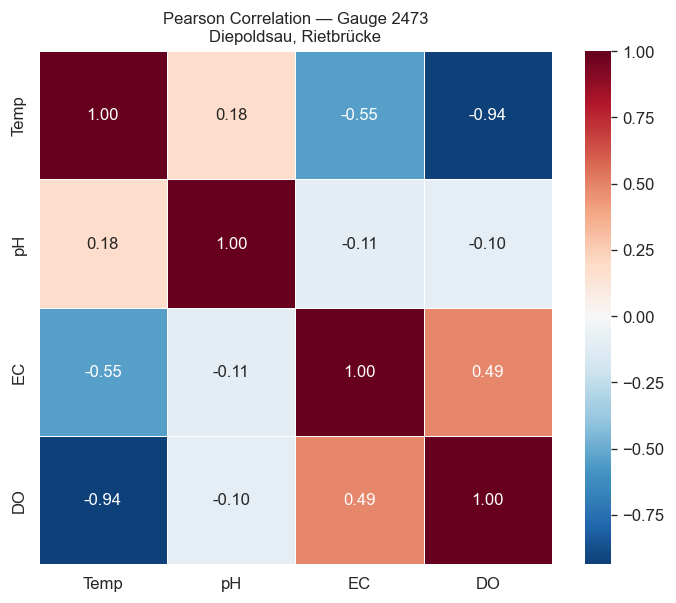

In [19]:
# Correlation heatmap for focus gauge (daily sensor variables)
corr = focus_df[SENSOR_COLS].corr()

fig, ax = plt.subplots(figsize=(6, 5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax,
            xticklabels=['Temp', 'pH', 'EC', 'DO'],
            yticklabels=['Temp', 'pH', 'EC', 'DO'])
ax.set_title(f'Pearson Correlation — Gauge {FOCUS_GAUGE}\n{focus_meta["gauge_name"]}',
             fontsize=10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_correlation_gauge_{FOCUS_GAUGE}.png', bbox_inches='tight')
plt.show()

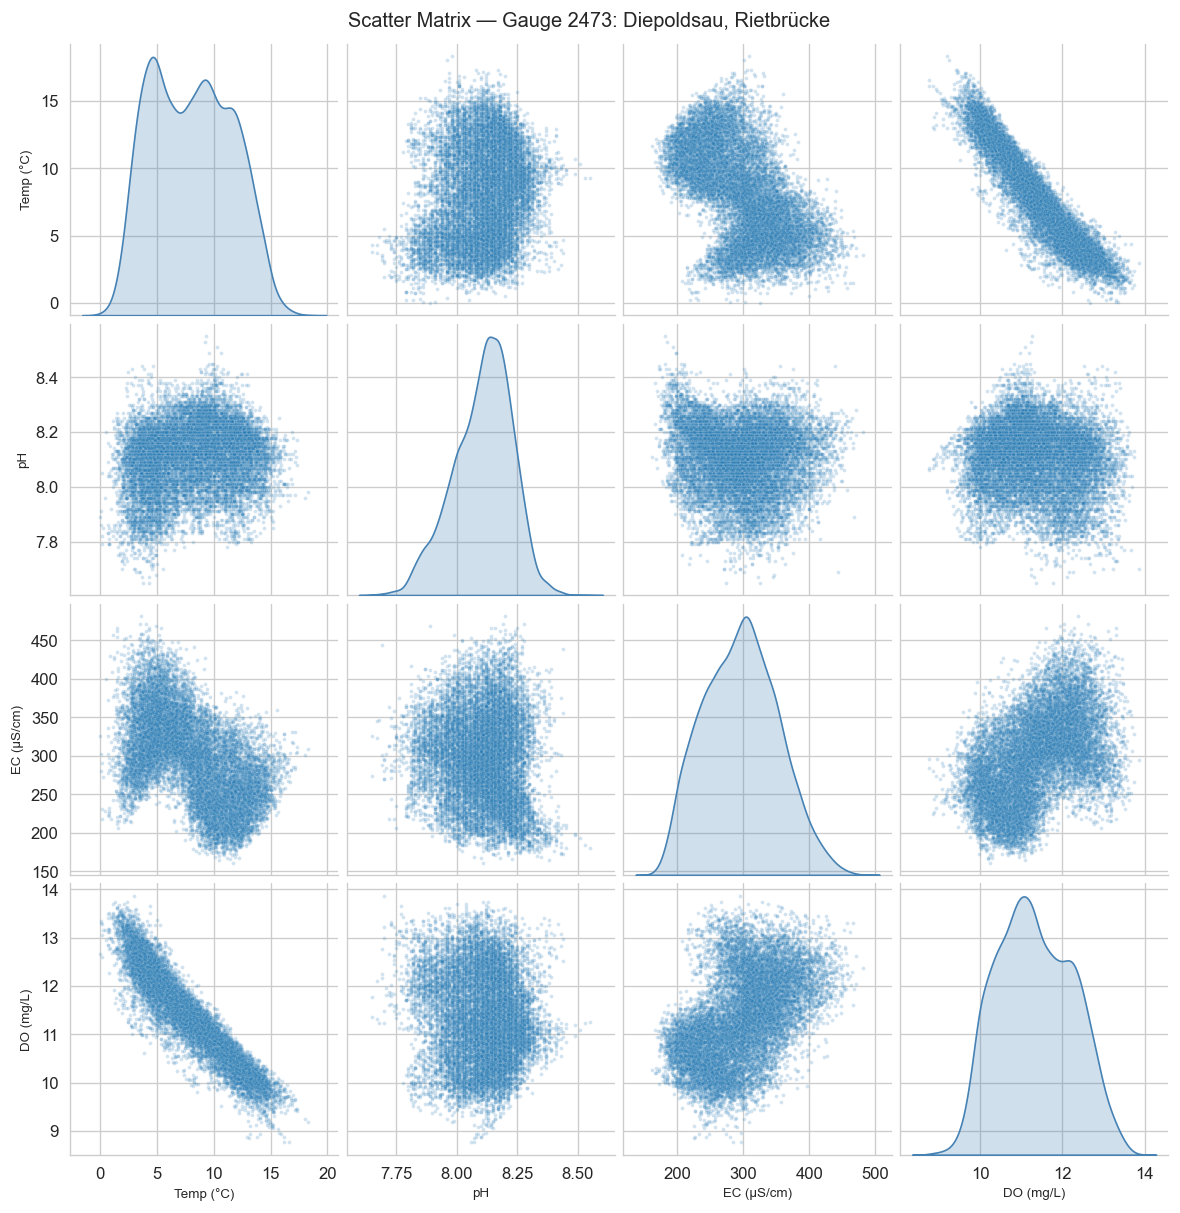

In [20]:
# Scatter plot matrix for focus gauge
plot_data = focus_df[SENSOR_COLS].dropna()
g = sns.pairplot(plot_data, diag_kind='kde', plot_kws={'alpha': 0.2, 's': 5},
                 diag_kws={'color': 'steelblue'},
                 vars=SENSOR_COLS)

var_short = ['Temp (°C)', 'pH', 'EC (µS/cm)', 'DO (mg/L)']
for i, ax_row in enumerate(g.axes):
    for j, ax in enumerate(ax_row):
        if i == len(SENSOR_COLS) - 1:
            ax.set_xlabel(var_short[j], fontsize=8)
        if j == 0:
            ax.set_ylabel(var_short[i], fontsize=8)

g.figure.suptitle(f'Scatter Matrix — Gauge {FOCUS_GAUGE}: {focus_meta["gauge_name"]}',
                  y=1.01)
g.figure.savefig(FIGURES_DIR / '01_scatter_matrix_gauge_{FOCUS_GAUGE}.png', bbox_inches='tight')
plt.show()

## 10. Missing Value Analysis

In [21]:
# Missing value summary per gauge for DO
missing_summary = []
for gauge_id in do_gauges:
    df = daily_data[gauge_id]
    if 'O2C_sensor' not in df.columns:
        continue
    s = df['O2C_sensor']
    total = len(s)
    missing = s.isna().sum()
    # Longest consecutive gap
    is_null = s.isna()
    if is_null.any():
        run_lengths = is_null.astype(int).groupby(
            (is_null != is_null.shift()).cumsum()).sum()
        longest_gap = run_lengths.max()
    else:
        longest_gap = 0
    missing_summary.append({
        'gauge_id':       gauge_id,
        'total_days':     total,
        'missing_pct':    missing / total * 100,
        'longest_gap_d':  longest_gap
    })

miss_df = pd.DataFrame(missing_summary).set_index('gauge_id')
print(miss_df.describe().round(1))
miss_df.sort_values('missing_pct').head(10)

       total_days  missing_pct  longest_gap_d
count        16.0         16.0           16.0
mean      14610.0         34.3         3209.7
std           0.0         28.2         3480.4
min       14610.0          2.7           33.0
25%       14610.0          8.6          179.8
50%       14610.0         25.5         2010.0
75%       14610.0         58.9         4801.8
max       14610.0         88.1        12784.0


,total_days,missing_pct,longest_gap_d
gauge_id,,,
2473,14610,2.683094,41
2009,14610,3.230664,77
2613,14610,3.744011,77
2143,14610,4.079398,33
2016,14610,10.136893,214
2174,14610,13.367556,1096
2415,14610,20.191650,2166
2044,14610,23.791923,1854
2410,14610,27.186858,3753


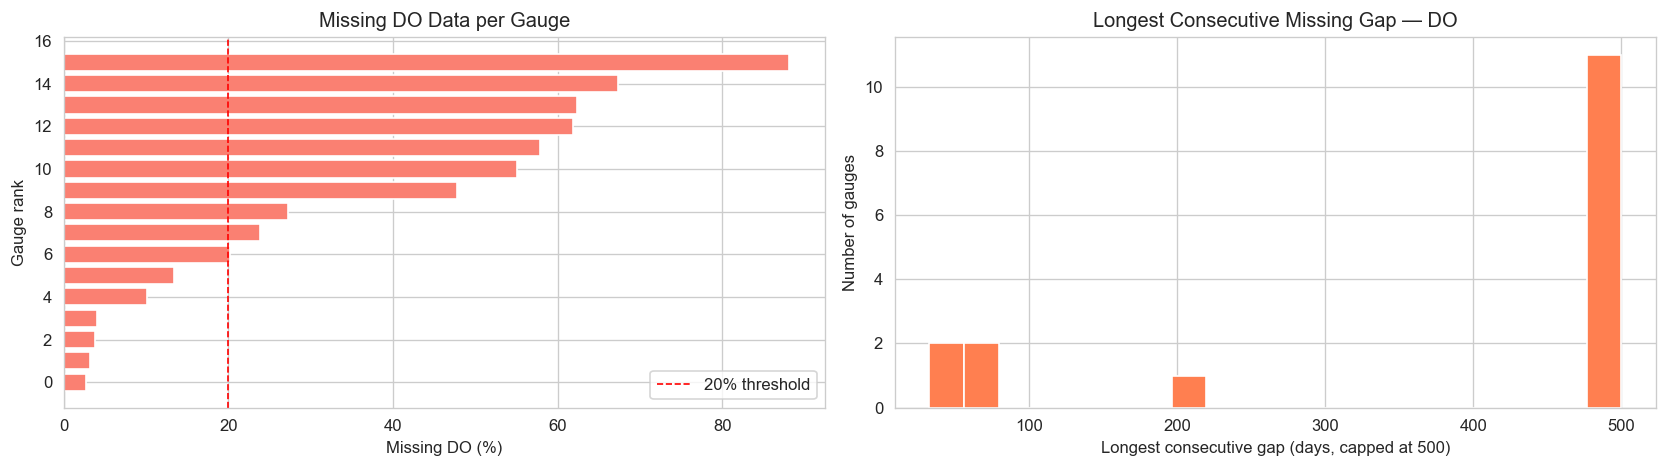

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].barh(range(len(miss_df)), miss_df.sort_values('missing_pct')['missing_pct'],
             color='salmon', edgecolor='white')
axes[0].axvline(20, color='red', linestyle='--', linewidth=1, label='20% threshold')
axes[0].set_xlabel('Missing DO (%)')
axes[0].set_ylabel('Gauge rank')
axes[0].set_title('Missing DO Data per Gauge')
axes[0].legend()

axes[1].hist(miss_df['longest_gap_d'].clip(upper=500), bins=20,
             color='coral', edgecolor='white')
axes[1].set_xlabel('Longest consecutive gap (days, capped at 500)')
axes[1].set_ylabel('Number of gauges')
axes[1].set_title('Longest Consecutive Missing Gap — DO')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_missing_value_analysis.png', bbox_inches='tight')
plt.show()

## 11. Stationarity Tests (Augmented Dickey-Fuller)

In [23]:
if HAS_STATSMODELS:
    adf_results = []
    for gauge_id in do_gauges[:10]:  # Test first 10 to keep runtime short
        df = daily_data[gauge_id]
        for col in ['temp_sensor', 'O2C_sensor']:
            if col not in df.columns:
                continue
            series = df[col].dropna()
            if len(series) < 50:
                continue
            try:
                adf_stat, p_val, _, _, _, _ = adfuller(series, autolag='AIC')
                adf_results.append({
                    'gauge_id':  gauge_id,
                    'variable':  col,
                    'adf_stat':  round(adf_stat, 3),
                    'p_value':   round(p_val, 4),
                    'stationary': p_val < 0.05
                })
            except Exception:
                pass

    adf_df = pd.DataFrame(adf_results)
    print('ADF Test Results (p < 0.05 → stationary):')
    print(adf_df.groupby(['variable','stationary']).size().to_string())
    adf_df
else:
    print('statsmodels not installed. Install with: pip install statsmodels')

ADF Test Results (p < 0.05 → stationary):
variable     stationary
O2C_sensor   True          10
temp_sensor  True          10


## 12. NAWA FRACHT Low-Frequency Chemistry

In [24]:
# Load all NAWA FRACHT files
nawaf_data = {}
for fpath in sorted(NAWAF_DIR.glob('camels_ch_chem_nawafracht_*.csv')):
    gauge_id = int(fpath.stem.split('_')[-1])
    df = pd.read_csv(fpath, parse_dates=['date_start', 'date_end'])
    # Use midpoint date as index
    df['date'] = df['date_start'] + (df['date_end'] - df['date_start']) / 2
    df = df.set_index('date').drop(columns=['date_start', 'date_end'])
    # Coerce all columns to numeric
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    nawaf_data[gauge_id] = df

print(f'Loaded {len(nawaf_data)} NAWA FRACHT files')
print(f'Variables: {list(list(nawaf_data.values())[0].columns)}')

Loaded 24 NAWA FRACHT files
Variables: ['alk', 'As', 'Ba', 'Br', 'Cd', 'Ca', 'Cl', 'Cr', 'Cu', 'doc', 'drp', 'ec25_sensor', 'ec20_lab', 'F', 'Fe', 'Pb', 'Mg', 'q_mean_sensor', 'Hg', 'Ni', 'NO3_N', 'O2C_sensor', 'O2S_sensor', 'pH_lab', 'pH_sensor', 'K', 'H4SiO4', 'Na', 'Sr', 'SO4', 'tfp', 'th', 'tn', 'toc', 'tp', 'tss', 'temp_sensor', 'Zn']


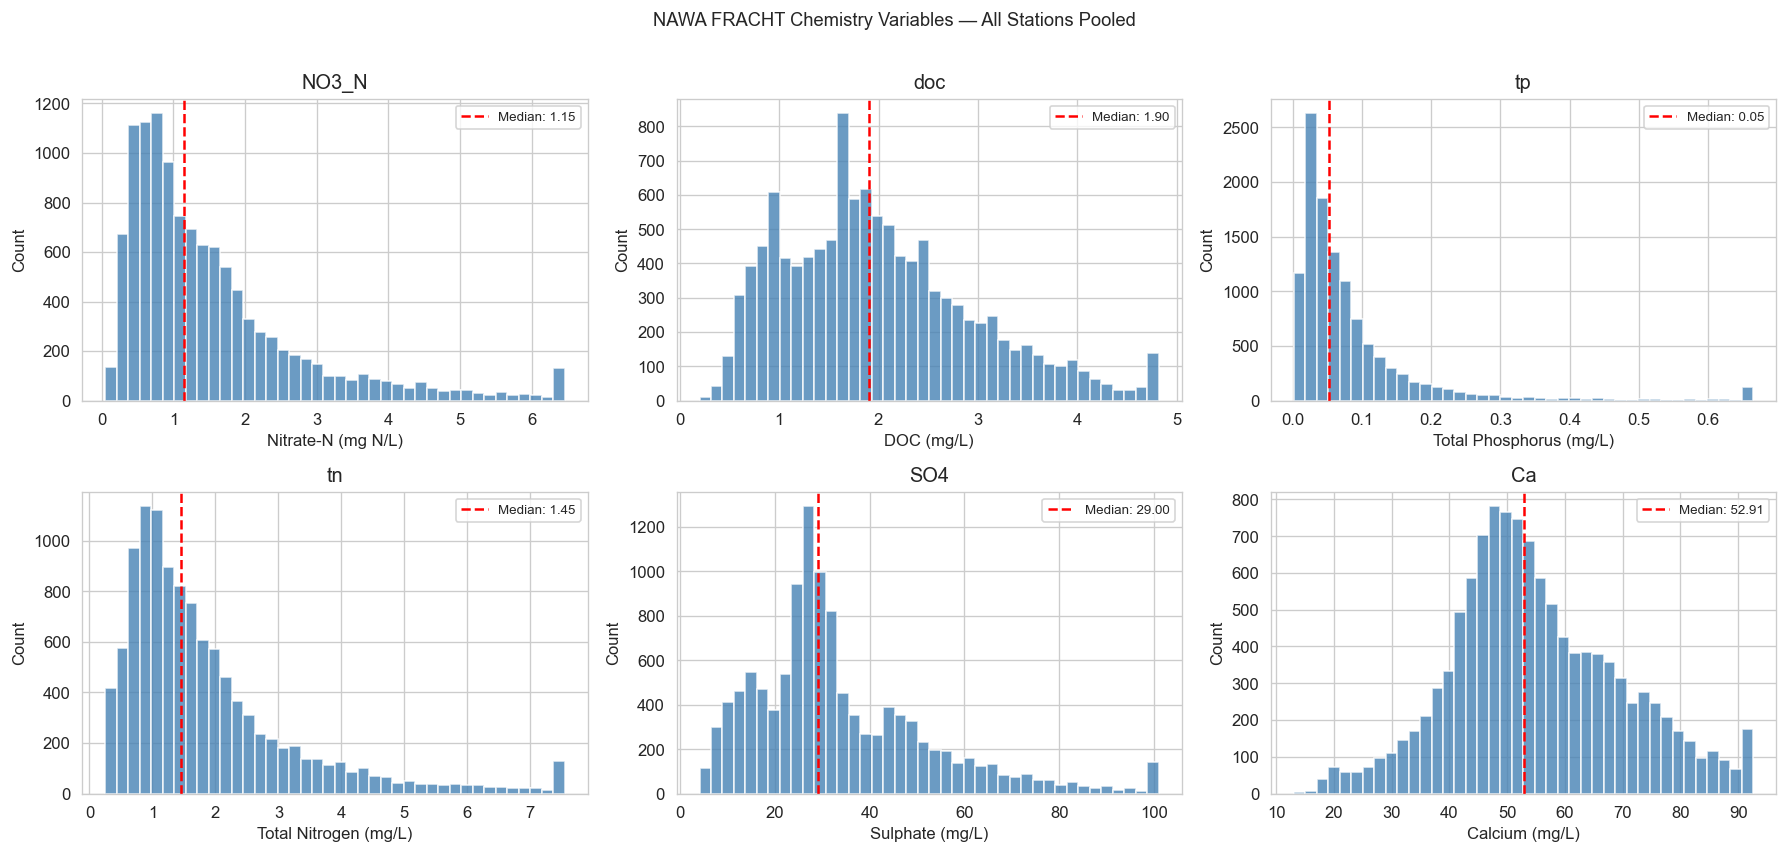

In [25]:
# Pool and plot key chemistry variables
CHEM_VARS = ['NO3_N', 'doc', 'tp', 'tn', 'SO4', 'Ca']
CHEM_LABELS = {
    'NO3_N': 'Nitrate-N (mg N/L)',
    'doc':   'DOC (mg/L)',
    'tp':    'Total Phosphorus (mg/L)',
    'tn':    'Total Nitrogen (mg/L)',
    'SO4':   'Sulphate (mg/L)',
    'Ca':    'Calcium (mg/L)'
}

all_nawaf = pd.concat(nawaf_data.values(), ignore_index=True)

available_chem = [v for v in CHEM_VARS if v in all_nawaf.columns and all_nawaf[v].notna().any()]

n_cols = 3
n_rows = int(np.ceil(len(available_chem) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, var in enumerate(available_chem):
    data = all_nawaf[var].dropna()
    axes[i].hist(data.clip(upper=data.quantile(0.99)), bins=40,
                 color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(data.median(), color='red', linestyle='--',
                    linewidth=1.5, label=f'Median: {data.median():.2f}')
    axes[i].set_xlabel(CHEM_LABELS.get(var, var))
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)
    axes[i].set_title(var)

# Hide unused subplots
for j in range(len(available_chem), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('NAWA FRACHT Chemistry Variables — All Stations Pooled', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_nawaf_chemistry_distributions.png', bbox_inches='tight')
plt.show()

## 13. Catchment Attributes — Land Cover

In [26]:
# Load land cover for all 115 catchments (most recent year: 2018)
lc_records = []
for fpath in LANDCOVER_DIR.glob('camels_ch_chem_landcover_*.csv'):
    gauge_id = int(fpath.stem.split('_')[-1])
    df = pd.read_csv(fpath)
    df['gauge_id'] = gauge_id
    lc_records.append(df)

lc_all = pd.concat(lc_records, ignore_index=True)
# Use most recent year
lc_2018 = lc_all[lc_all['date'] == lc_all['date'].max()].copy()

lc_cols = ['crop_perc','dwood_perc','ewood_perc','grass_perc','ice_perc',
           'urban_perc','rock_perc','loose_rock_perc','scrub_perc',
           'inwater_perc','wetlands_perc','mixed_wood_perc']
lc_cols = [c for c in lc_cols if c in lc_2018.columns]

print(f'Loaded land cover for {lc_2018["gauge_id"].nunique()} catchments')
lc_2018[lc_cols].describe().round(1)

Loaded land cover for 115 catchments


,crop_perc,dwood_perc,ewood_perc,grass_perc,ice_perc,urban_perc,rock_perc,loose_rock_perc,scrub_perc,inwater_perc,wetlands_perc,mixed_wood_perc
count,115.0,115.0,115.0,115.0,115.0,115.0,115.0,115.0,115.0,115.0,115.0,115.0
mean,17.8,3.0,14.2,21.8,3.2,4.9,8.1,6.2,3.1,1.4,3.6,12.6
std,19.6,5.6,9.8,13.8,8.1,4.7,10.0,7.3,3.5,2.5,4.5,11.1
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,1.1,0.0,8.0,12.3,0.0,1.5,0.0,0.0,0.8,0.0,0.2,6.0
50%,11.6,1.2,13.6,22.2,0.0,4.3,4.4,3.9,2.3,0.1,2.4,10.8
75%,28.4,3.7,17.2,28.9,1.8,7.3,13.6,10.0,3.7,1.7,5.4,16.6
max,81.6,49.2,61.9,77.8,62.2,28.0,35.4,34.2,17.0,17.4,28.3,72.6


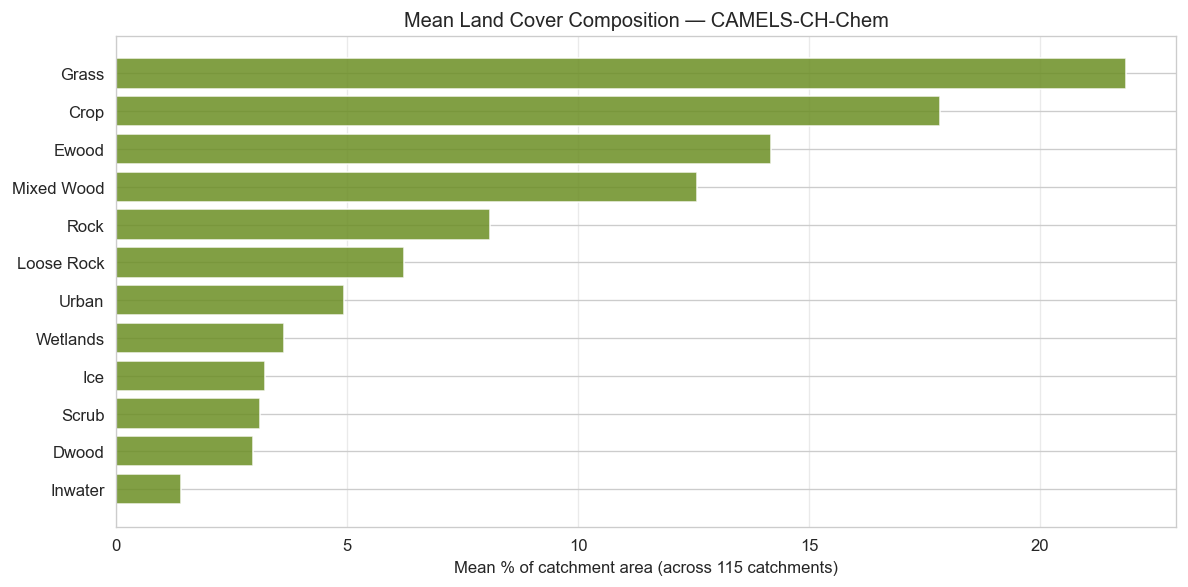

In [27]:
# Mean land cover composition across all catchments
lc_means = lc_2018[lc_cols].mean().sort_values(ascending=True)
lc_labels = {c: c.replace('_perc','').replace('_',' ').title() for c in lc_cols}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh([lc_labels.get(c, c) for c in lc_means.index],
               lc_means.values, color='olivedrab', edgecolor='white', alpha=0.85)
ax.set_xlabel('Mean % of catchment area (across 115 catchments)')
ax.set_title('Mean Land Cover Composition — CAMELS-CH-Chem')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_land_cover_composition.png', bbox_inches='tight')
plt.show()

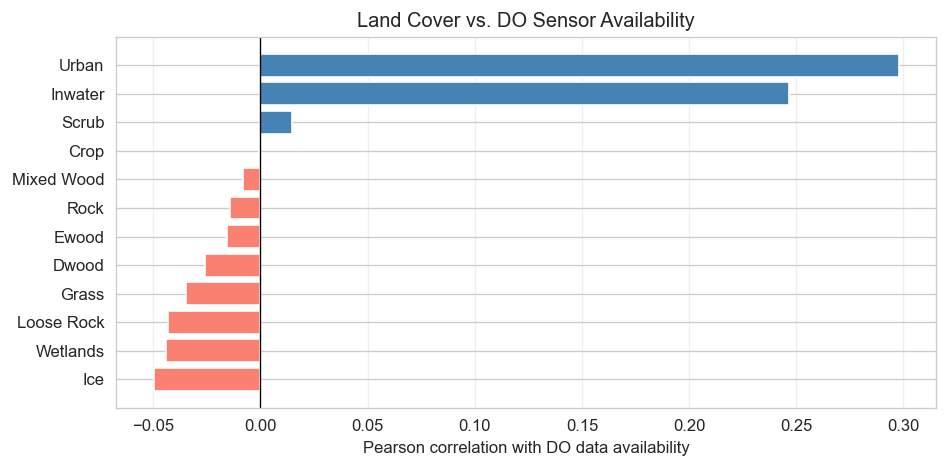

In [28]:
# Merge land cover with DO availability data
do_avail_series = avail_df['O2C_sensor'].rename('do_availability_pct')
lc_do = lc_2018.set_index('gauge_id')[lc_cols].join(do_avail_series)

# Correlation: land cover vs DO availability
lc_do_corr = lc_do.corr()['do_availability_pct'].drop('do_availability_pct').sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['salmon' if v < 0 else 'steelblue' for v in lc_do_corr.values]
ax.barh([lc_labels.get(c, c) for c in lc_do_corr.index],
        lc_do_corr.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with DO data availability')
ax.set_title('Land Cover vs. DO Sensor Availability')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_landcover_do_correlation.png', bbox_inches='tight')
plt.show()

## 14. EDA Summary

In [29]:
print('=' * 55)
print('AAREML — EDA SUMMARY')
print('=' * 55)
print(f'Total gauges:                  {len(daily_data)}')
print(f'Gauges with DO data (>10%):    {len(do_gauges)}')
print(f'NAWA FRACHT (full chemistry):  {len(nawaf_data)}')
print(f'Land cover catchments:         {lc_2018["gauge_id"].nunique()}')
print(f'Full date range:               1981 – 2020')
print()
print('DO gauges identified for modelling:')
for g in do_gauges:
    row = meta[meta['gauge_id'] == g]
    if len(row) > 0:
        r = row.iloc[0]
        do_pct = avail_df.loc[g, 'O2C_sensor'] if g in avail_df.index else 0
        print(f'  {g:5d}  {str(r["gauge_name"]):30s}  {str(r["water_body_name"]):20s}  DO: {do_pct:.0f}%')
print()
print('Focus gauge for modelling (notebook 03):', FOCUS_GAUGE)
print('=' * 55)

AAREML — EDA SUMMARY
Total gauges:                  86
Gauges with DO data (>10%):    16
NAWA FRACHT (full chemistry):  24
Land cover catchments:         115
Full date range:               1981 – 2020

DO gauges identified for modelling:
   2473  Diepoldsau, Rietbrücke          Rhein                 DO: 97%
   2009  Porte du Scex                   Rhône                 DO: 97%
   2613  Weil, Palmrainbrücke (D)        Rhein                 DO: 96%
   2143  Rekingen                        Rhein                 DO: 96%
   2016  Brugg                           Aare                  DO: 90%
   2174  Chancy, Aux Ripes               Rhône                 DO: 87%
   2415  Rheinsfelden                    Glatt                 DO: 80%
   2044  Andelfingen                     Thur                  DO: 76%
   2410  Ruggell                         Liechtensteiner Binnenkanal  DO: 73%
   2085  Hagneck                         Aare                  DO: 52%
   2462  S-chanf                         Inn 